In [37]:
import torch
import torch_harmonics.distributed as dist
import torch_harmonics as th
import xarray as xr
import numpy as np
import xesmf as xe
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from subs1_utils import precompute_latitudes, bscst

import warnings
warnings.filterwarnings("ignore")

cmap = 'turbo'

In [38]:
### Define Spectral Truncation Desired and Consistent
###    Gausian Grid
zw = 63
mw = 63
jmax = 96
imax = 192
#
# Since the this is an annual cycle simulation the preprocessed data is relatively large and is saved on a data disk
#
outpath = '/data/esplab/kpegion/projects/AGCM/AnnualCycle/'
#
###
###
###
###
# Setup necessary element for interpolation onto model Gaussian Grid
# Get the Gaussian latitudes on equally spaced longitudes (xr.dataset)
cost_lg, wlg, lats = precompute_latitudes(jmax)
lats = 90-180*lats/(np.pi)
lons = np.linspace(0.0,360.0-360.0/imax,imax)
dlatlon = xr.Dataset({"lat": lats, "lon": lons})

# Instantiate  grid to spectral (dsht) and spectral to grid (disht) transforms
#
vsht = th.RealVectorSHT(jmax, imax, lmax=mw, mmax=zw, grid="legendre-gauss", csphase=False)
dsht = dist.DistributedRealSHT(jmax, imax, lmax=mw, mmax=zw, grid="legendre-gauss", csphase=False)
disht = dist.DistributedInverseRealSHT(jmax, imax, lmax=mw, mmax=zw, grid="legendre-gauss", csphase=False)
dvsht = dist.DistributedRealVectorSHT(jmax, imax, lmax=mw, mmax=zw, grid="legendre-gauss", csphase=False)
divsht = dist.DistributedInverseRealVectorSHT(jmax, imax, lmax=mw, mmax=zw, grid="legendre-gauss", csphase=False)

In [39]:
#
ftemp = '/data/esplab/shared/obs/gridded/atm/precip/daily/CMORPH/CMORPH_V1.0_ADJ_0.25deg-DLY_00Z_*.nc'
Dprec = xr.open_mfdataset(ftemp,autoclose=True)
Dprec

<xarray.Dataset>
Dimensions:      (time: 9740, nv: 2, lat: 480, lon: 1440)
Coordinates:
  * time         (time) datetime64[ns] 1998-01-01 1998-01-02 ... 2024-08-31
  * lat          (lat) float32 -59.88 -59.62 -59.38 -59.12 ... 59.38 59.62 59.88
  * lon          (lon) float32 0.125 0.375 0.625 0.875 ... 359.4 359.6 359.9
Dimensions without coordinates: nv
Data variables:
    time_bounds  (time, nv) datetime64[ns] dask.array<chunksize=(1, 2), meta=np.ndarray>
    lat_bounds   (time, lat, nv) float32 dask.array<chunksize=(1, 480, 2), meta=np.ndarray>
    lon_bounds   (time, lon, nv) float32 dask.array<chunksize=(1, 1440, 2), meta=np.ndarray>
    cmorph       (time, lat, lon) float32 dask.array<chunksize=(1, 480, 1440), meta=np.ndarray>
Attributes: (12/57)
    ncei_template_version:      NCEI_NetCDF_Grid_template_V2.0
    title:                      NOAA Climate Data Record (CDR) of CPC Morphin...
    keywords:                   Precipitation, Satellite, High-Resolution, Gl...
    summary:                    The CMORPH CDR is a reprocessed and bias-corr...
    references:                 Xie, P., et al. (2017), Reprocessed, Bias-Cor...
    Conventions:                CF-1.6, ACDD-1.3
    ...                         ...
    geospatial_lat_resolution:  0.25
    geospatial_lat_units:       degrees_north
    geospatial_lon_min:         0.0
    geospatial_lon_max:         360.0
    geospatial_lon_resolution:  0.25
    geospatial_lon_units:       degrees_east

In [40]:
#
# Remove NaNs and interpolate to model grid and convert to xarray
#
#
tmp = Dprec.cmorph
tmp = np.where(np.isnan(tmp), 0.0, tmp)
#
regridder_oi2 = xe.Regridder(Dprec,dlatlon,'bilinear')
precip = regridder_oi2(tmp)
#
times = Dprec.cmorph['time']
drain = xr.Dataset({'precip': (['time','lat','lon'],precip)}, 
                        coords={'time': times, 'lat': lats, 'lon': lons})
#
drain

<xarray.Dataset>
Dimensions:  (time: 9740, lat: 96, lon: 192)
Coordinates:
  * time     (time) datetime64[ns] 1998-01-01 1998-01-02 ... 2024-08-31
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
Data variables:
    precip   (time, lat, lon) float32 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

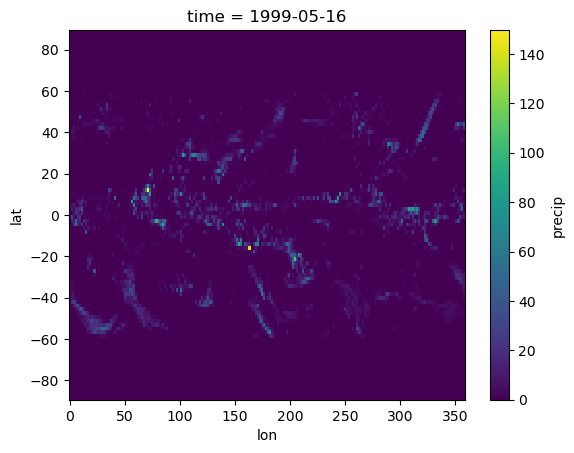

In [41]:
drain.precip[500,:,:].plot()

In [42]:
foomean = drain.precip.sel(time=slice('1997-01-01','2020-12-31')).mean(dim='time')

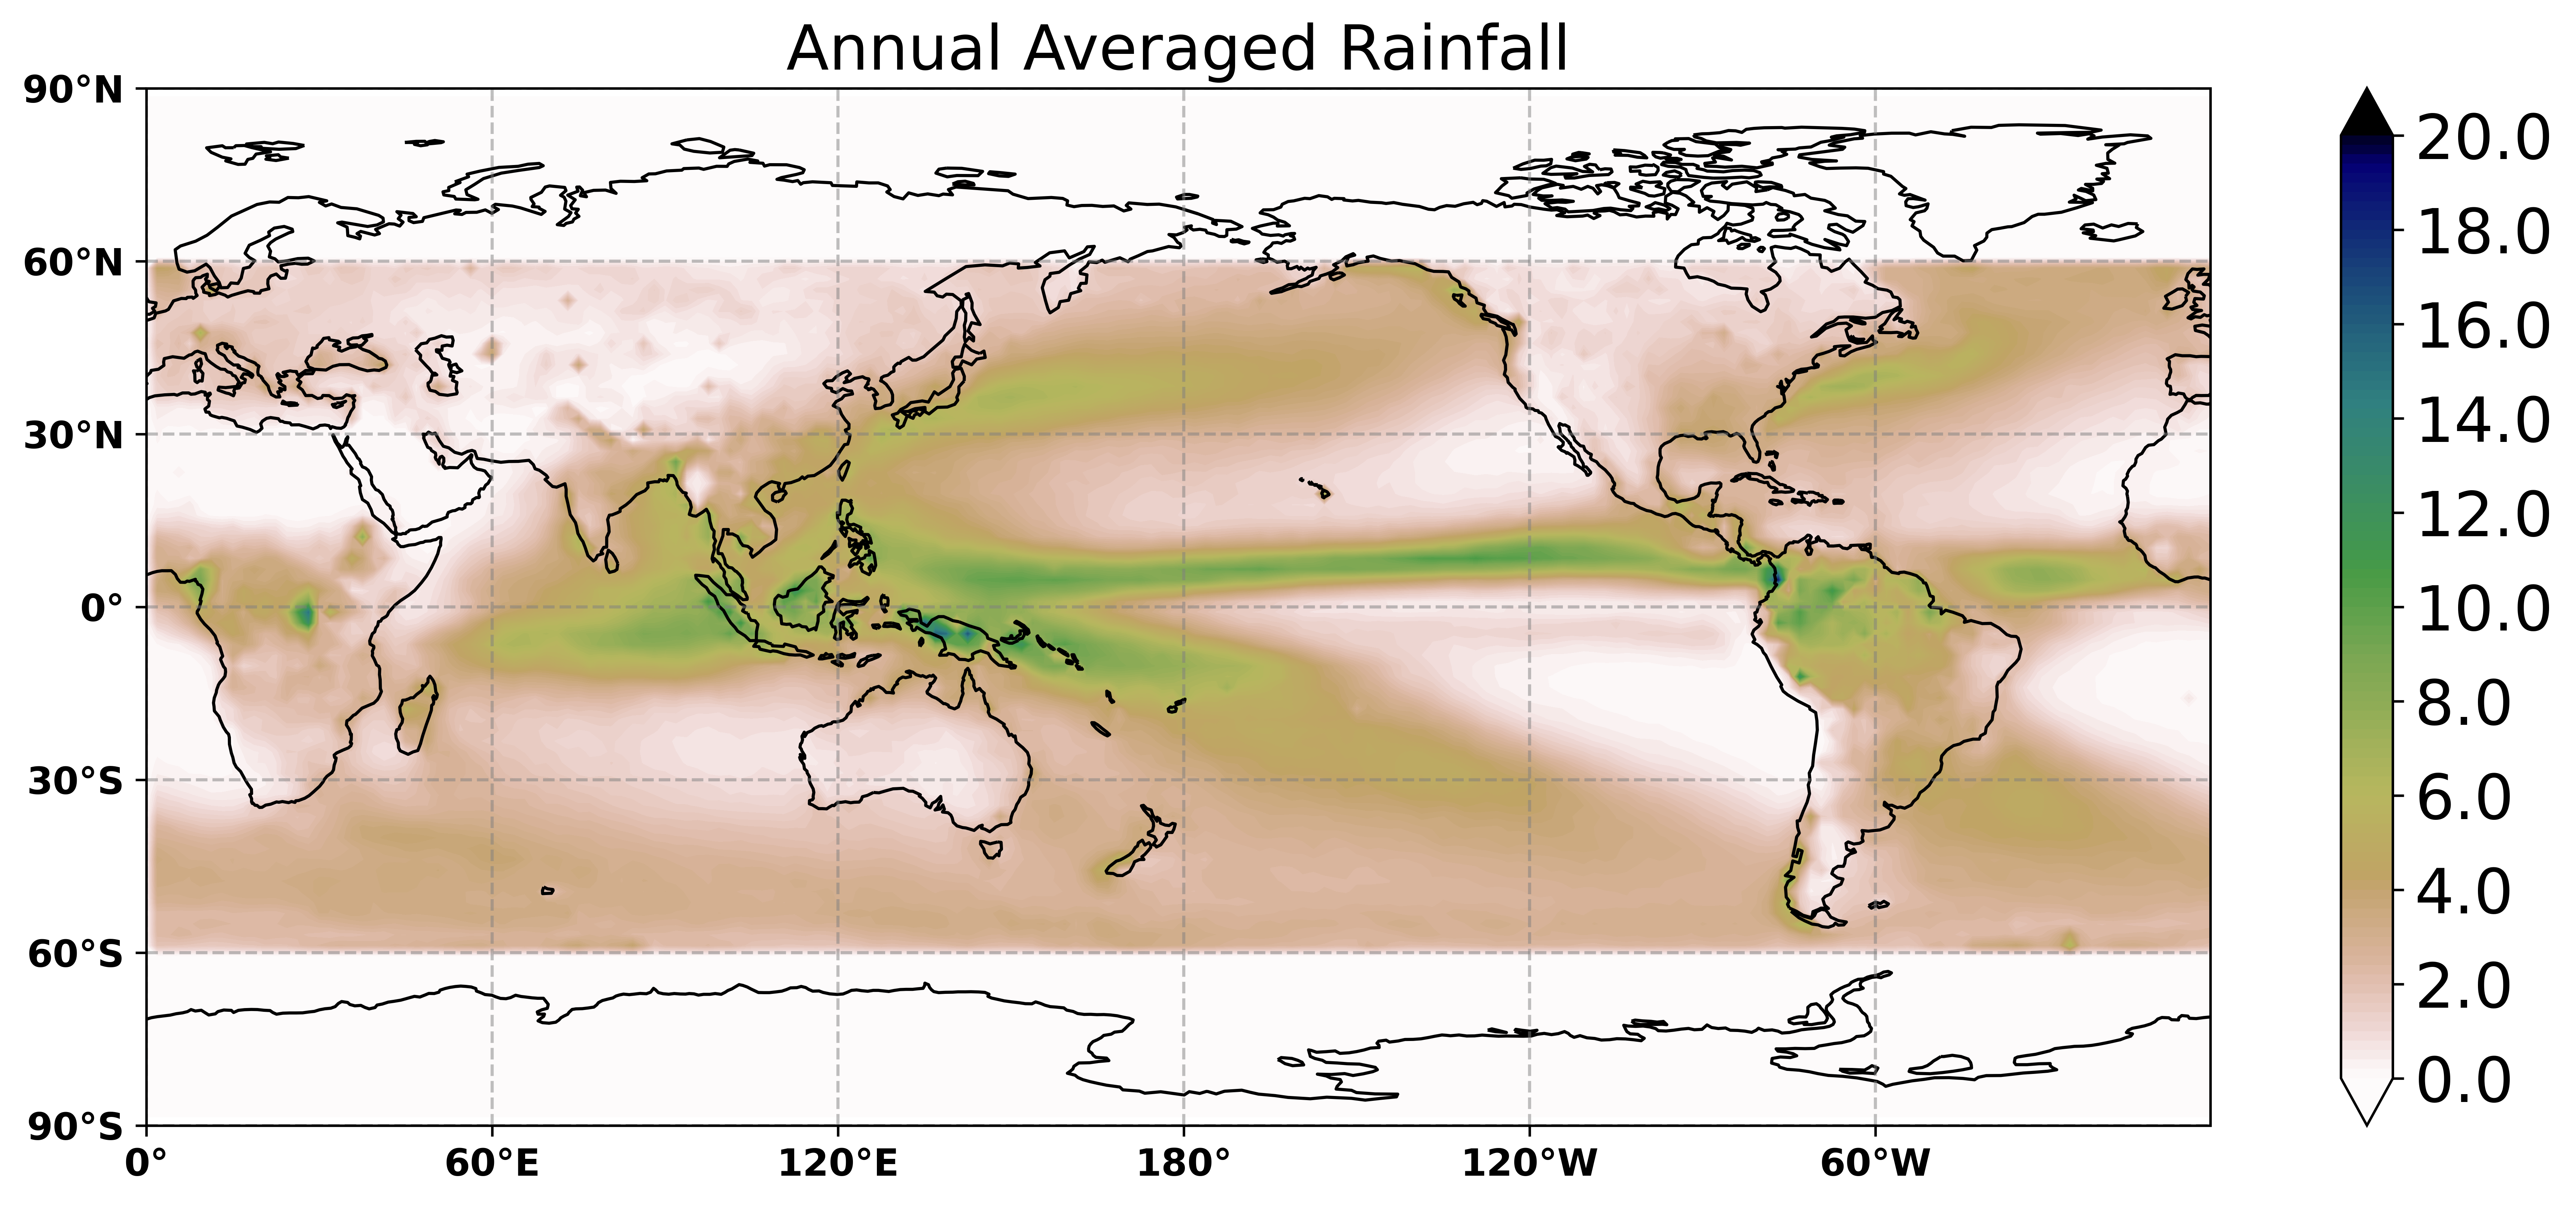

In [43]:
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
#
#from cartopy.feature import NaturalEarthFeature
#
#coast = NaturalEarthFeature(category='physical', scale='10m',
#                            facecolor='none', name='coastline')
#
fig = plt.figure(figsize=(15,6),dpi=600)
#
lccProjParams = {'central_longitude'  : 180.0} # same as lon_0
proj = ccrs.PlateCarree(**lccProjParams)
ax=plt.axes(projection=proj)
lons = foomean['lon']
lats = foomean['lat']
conlevels = np.linspace(0,20,101)
#datacyc,loncyc=add_cyclic_point(rat1,coord=lons)
contour=ax.contourf(lons, lats, foomean,conlevels,cmap=plt.cm.gist_earth_r, transform = ccrs.PlateCarree(),
                    extend='both')
###
cont_ints = np.linspace(0,20,11)
cbar = plt.colorbar(contour,ticks=cont_ints)
#####cbar.set_label('m/s',fontsize=20)
cbar.set_ticklabels(cont_ints)
cbar.ax.tick_params(labelsize=20)
###
plt.title('Annual Averaged Rainfall',fontdict = {'fontsize' : 20})
###
ax.coastlines()
ax.set_xticks([0,60,120,180,240,300], crs=ccrs.PlateCarree())
ax.set_xticklabels([0,60,120,180,240,300], color='black', weight='bold',size=12)
ax.set_yticks([-90,-60,-30,0,30,60,90], crs=ccrs.PlateCarree())
ax.set_yticklabels([-90,-60,-30,0,30,60,90], color='black', weight='bold',size=12)
lon_formatter = cticker.LongitudeFormatter()
lat_formatter = cticker.LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
###
ax.grid(linewidth=1, color='grey', alpha=0.5, linestyle='--')
#feature = ax.add_feature(coast, edgecolor='gray')

In [44]:
#
# Now let's make a map of the shape and scale parameters that can be used as
# input to simple physics model.
#
mean = drain.precip.groupby('time.dayofyear').mean(dim='time')
anom = drain.precip.groupby('time.dayofyear') - mean
#
#
var = (anom*anom).groupby('time.dayofyear').mean(dim='time') # daily variance
times = pd.date_range(start = '1952-01-01', end='1952-12-31', freq='D')
dvar = xr.Dataset({'variance': (['time','lat','lon'],var.values)}, 
                  coords={'time': times, 'lat': lats, 'lon': lons})
dmean = xr.Dataset({'tmean': (['time','lat','lon'],mean.values)}, 
                  coords={'time': times, 'lat': lats, 'lon': lons})
var_monthly = dvar.resample(time='M').mean()
mean_monthly = dmean.resample(time='M').mean()
#
sigma_monthly = np.sqrt(var_monthly.variance)
shape = ((mean_monthly.tmean/sigma_monthly)**2)
shape = np.where(np.isnan(shape), 0.0, shape)
scale = var_monthly.variance/mean_monthly.tmean
scale = np.where(np.isnan(scale), 0.0, scale)
#

In [45]:
# 
# Write annual cycle of total rainfall
#
torch.save(mean,outpath+'total_heatingAC.pt')

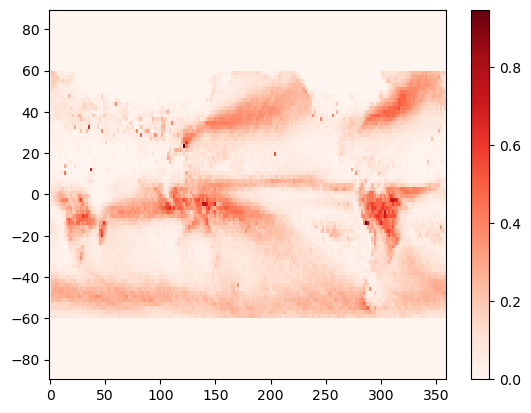

In [46]:
#
Lon, Lat = np.meshgrid(lons, lats)
plt.pcolormesh(Lon, Lat, shape[1], cmap='Reds')
plt.colorbar()

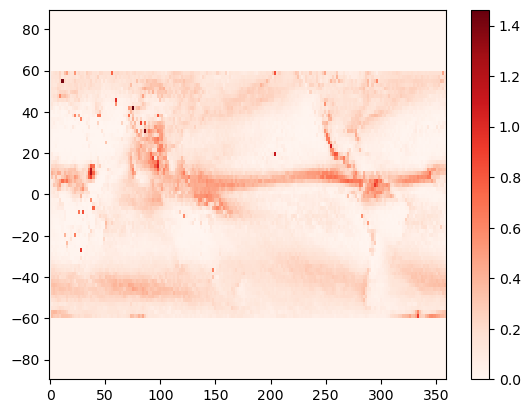

In [47]:
#
Lon, Lat = np.meshgrid(lons, lats)
plt.pcolormesh(Lon, Lat, shape[6], cmap='Reds')
plt.colorbar()

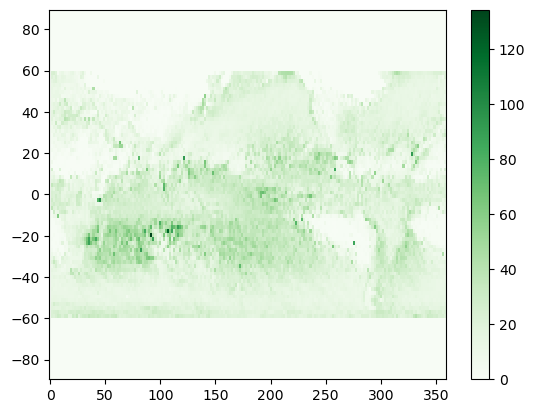

In [48]:
#
Lon, Lat = np.meshgrid(lons, lats)
plt.pcolormesh(Lon, Lat, scale[1], cmap='Greens')
plt.colorbar()

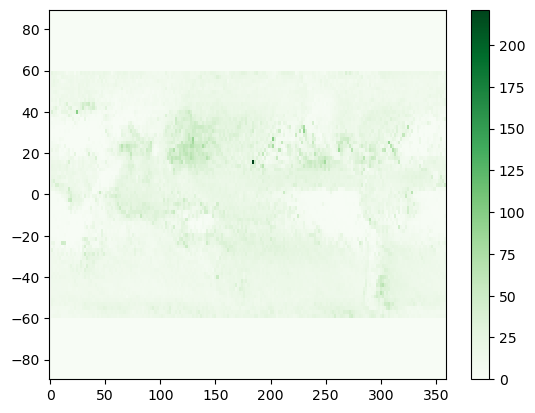

In [49]:
#
Lon, Lat = np.meshgrid(lons, lats)
plt.pcolormesh(Lon, Lat, scale[6], cmap='Greens')
plt.colorbar()

In [50]:
#
# Now upsample shape to daily
#
times = times = pd.date_range(start = '1950-01-01', end='1951-01-01', freq='M')
#
# lats, lons are defined
#
dT1 = xr.Dataset({'shape': (['time','lat','lon'],shape)},coords={'time': times,'lat': lats, 'lon': lons})
times = times = pd.date_range(start = '1951-01-01', end='1952-01-01', freq='M')
dT2 = xr.Dataset({'shape': (['time','lat','lon'],shape)},coords={'time': times, 'lat': lats, 'lon': lons})
times = times = pd.date_range(start = '1952-01-01', end='1953-01-01', freq='M')
dT3 = xr.Dataset({'shape': (['time','lat','lon'],shape)},coords={'time': times, 'lat': lats, 'lon': lons})
dT = xr.concat([dT1,dT2,dT3],dim='time')
#
Daily = dT.resample(time='D').interpolate('cubic')
Daily

<xarray.Dataset>
Dimensions:  (time: 1066, lat: 96, lon: 192)
Coordinates:
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
  * time     (time) datetime64[ns] 1950-01-31 1950-02-01 ... 1952-12-31
Data variables:
    shape    (time, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

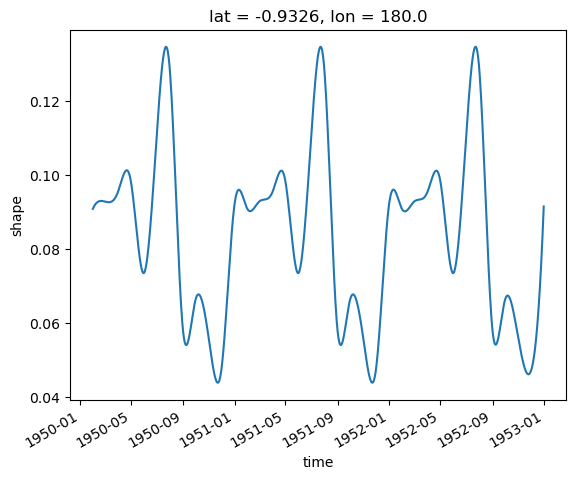

In [51]:
Daily.shape[:,48,96].plot()

In [52]:
#
foo = Daily.shape[335:700]
foo = np.where(foo < 0.0, 0.0, foo)
torch.save(foo,outpath+'shapeAC.pt')

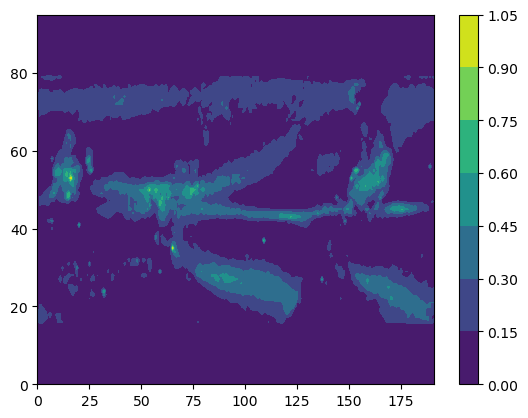

In [60]:
plt.contourf(foo[0,:,:])
plt.colorbar()

In [61]:
foo = Daily.shape[335:700]
foo = np.where(foo < 0.0, 0.0, 0.0)
torch.save(foo,outpath+'shape_noheating.pt')

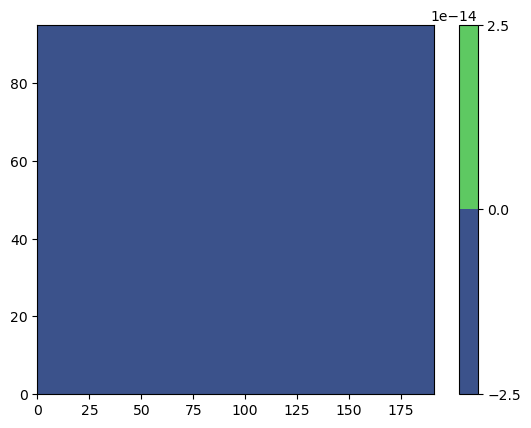

In [62]:
plt.contourf(foo[0,:,:])
plt.colorbar()

In [63]:
#
# Now upsample scale to daily
#
times = times = pd.date_range(start = '1950-01-01', end='1951-01-01', freq='M')
#
# lats, lons, are defined
#
dT1 = xr.Dataset({'scale': (['time','lat','lon'],scale)},coords={'time': times,'lat': lats, 'lon': lons})
times = times = pd.date_range(start = '1951-01-01', end='1952-01-01', freq='M')
dT2 = xr.Dataset({'scale': (['time','lat','lon'],scale)},coords={'time': times, 'lat': lats, 'lon': lons})
times = times = pd.date_range(start = '1952-01-01', end='1953-01-01', freq='M')
dT3 = xr.Dataset({'scale': (['time','lat','lon'],scale)},coords={'time': times, 'lat': lats, 'lon': lons})
dT = xr.concat([dT1,dT2,dT3],dim='time')
#
Daily = dT.resample(time='D').interpolate('cubic')
Daily

<xarray.Dataset>
Dimensions:  (time: 1066, lat: 96, lon: 192)
Coordinates:
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
  * time     (time) datetime64[ns] 1950-01-31 1950-02-01 ... 1952-12-31
Data variables:
    scale    (time, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

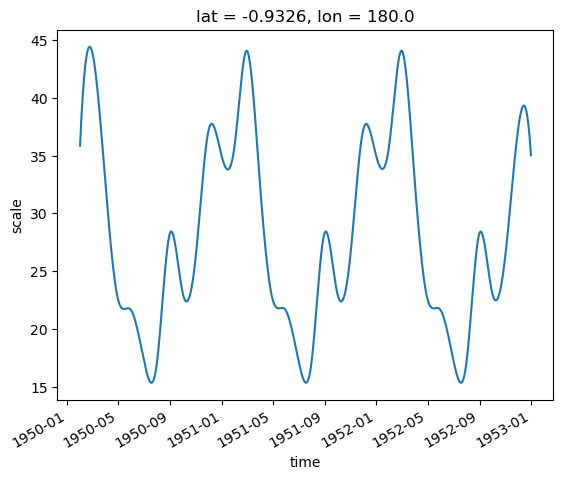

In [64]:
Daily.scale[:,48,96].plot()

In [65]:
#
foo = Daily.scale[335:700]
foo = np.where(foo < 0.0, 0.0, foo)
torch.save(foo,outpath+'scaleAC.pt')

In [66]:
foo = Daily.scale[335:700]
foo = np.where(foo < 0.0, 0.0, 0.0)
torch.save(foo,outpath+'scale_noheating.pt')

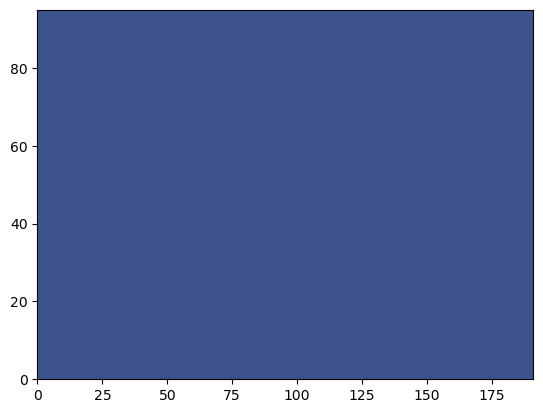

In [68]:
plt.contourf(foo[180,:,:])

In [69]:
#
# Now shape and scale for warm ENSO events
#
wyrs = ['2002','2009','2015'] # Warm years start
wyre = ['2003','2010','2016'] # Warm years end - NOTE: 2016 is a leap year (so is 1952)
#
times = pd.date_range(start = '1950-01-01', end='1952-12-31', freq='D')
#
anom_warm1 = anom.sel(time=slice('2002-07-01','2003-06-30'))
total_warm1 = drain.precip.sel(time=slice('2002-07-01','2003-06-30'))
anom_warm2 = anom.sel(time=slice('2009-07-01','2010-06-30'))
total_warm2 = drain.precip.sel(time=slice('2009-07-01','2010-06-30'))
anom_warm3 = anom.sel(time=slice('2015-07-01','2016-06-30'))
total_warm3 = drain.precip.sel(time=slice('2015-07-01','2016-06-30'))
anom_warm = xr.concat([anom_warm1,anom_warm2,anom_warm3],dim='time')
total_warm = xr.concat([total_warm1,total_warm2,total_warm3],dim='time')
#
danom = xr.Dataset({'anom': (['time','lat','lon'],anom_warm.values)}, 
                   coords={'time': times, 'lat': lats, 'lon': lons})
dtotal = xr.Dataset({'total': (['time','lat','lon'],total_warm.values)}, 
                   coords={'time': times, 'lat': lats, 'lon': lons})
#
mean_warm = dtotal.total.groupby('time.dayofyear').mean(dim='time')
var_warm = (danom.anom*danom.anom).groupby('time.dayofyear').mean(dim='time') # daily variance
#
#### Time shift data so that daily climo starts on 1 January
#
mean_warm_shift = mean_warm*0.0
var_warm_shift = var_warm*0.0
it_shift = 182
for it in range(366):
    mean_warm_shift[it]=mean_warm[it_shift]
    var_warm_shift[it]=var_warm[it_shift]
    it_shift = it_shift + 1
    if ( it_shift == 366 ):
        it_shift = 0
    #
#
#
times = pd.date_range(start = '1952-01-01', end='1952-12-31', freq='D')
dvar = xr.Dataset({'variance': (['time','lat','lon'],var_warm_shift.values)}, 
                  coords={'time': times, 'lat': lats, 'lon': lons})
dmean = xr.Dataset({'tmean': (['time','lat','lon'],mean_warm_shift.values)}, 
                  coords={'time': times, 'lat': lats, 'lon': lons})
var_monthly = dvar.resample(time='M').mean()
mean_monthly = dmean.resample(time='M').mean()
#
sigma_monthly = np.sqrt(var_monthly.variance)
shape_warm = ((mean_monthly.tmean/sigma_monthly)**2)
shape_warm = np.where(np.isnan(shape_warm), 0.0, shape_warm)
scale_warm = var_monthly.variance/mean_monthly.tmean
scale_warm = np.where(np.isnan(scale_warm), 0.0, scale_warm)
scale_warm = np.where(scale_warm > 300.0, 0.0, scale_warm)

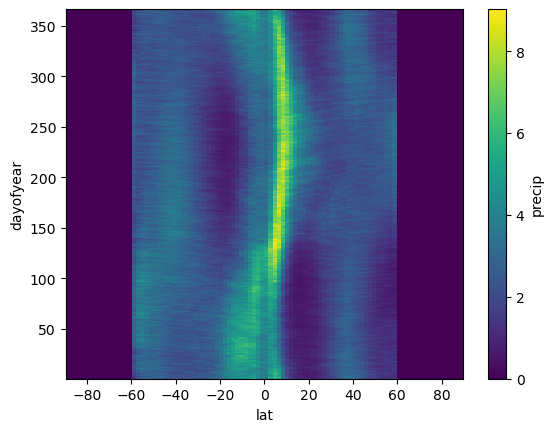

In [70]:
mean.mean(dim='lon').plot()

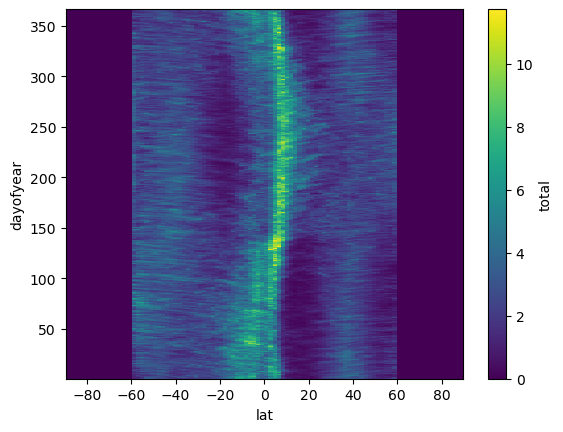

In [71]:
mean_warm_shift.mean(dim='lon').plot()

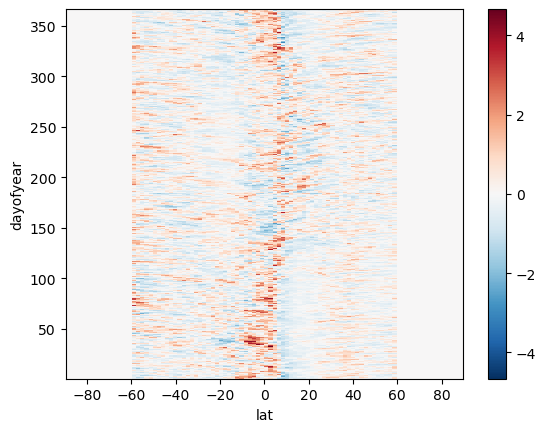

In [72]:
(mean_warm_shift-mean).mean(dim='lon').plot()

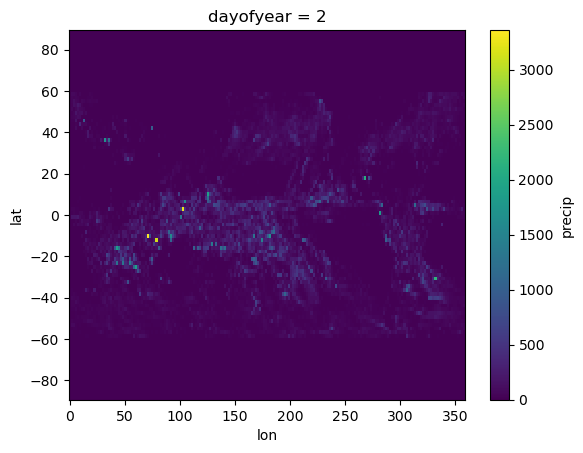

In [73]:
var[1].plot()

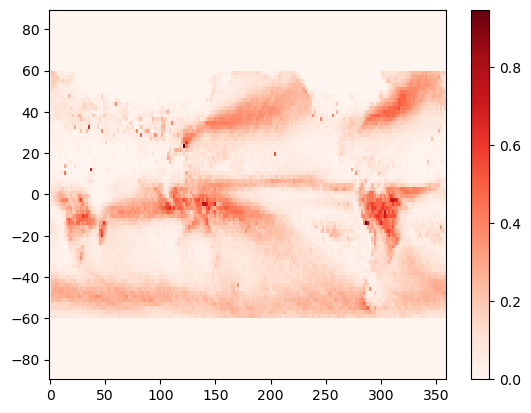

In [74]:
#
Lon, Lat = np.meshgrid(lons, lats)
plt.pcolormesh(Lon, Lat, shape[1], cmap='Reds')
plt.colorbar()

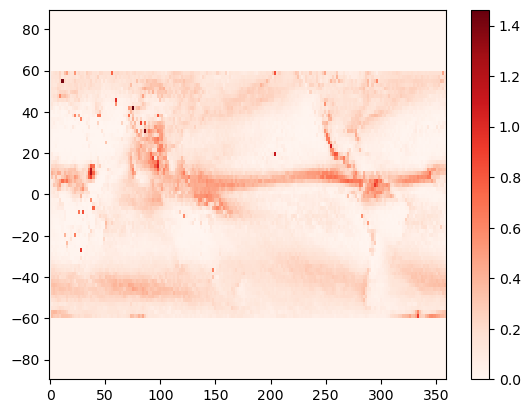

In [75]:
#
Lon, Lat = np.meshgrid(lons, lats)
plt.pcolormesh(Lon, Lat, shape[6], cmap='Reds')
plt.colorbar()

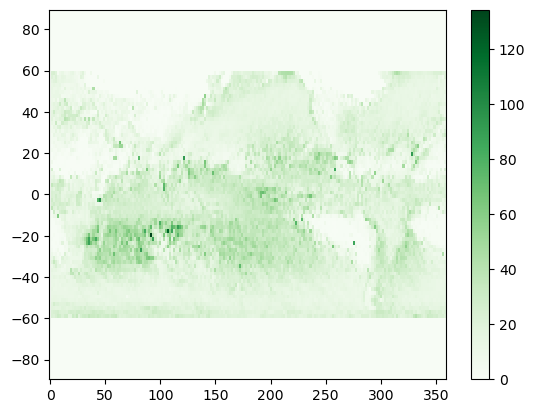

In [76]:
#
Lon, Lat = np.meshgrid(lons, lats)
plt.pcolormesh(Lon, Lat, scale[1], cmap='Greens')
plt.colorbar()

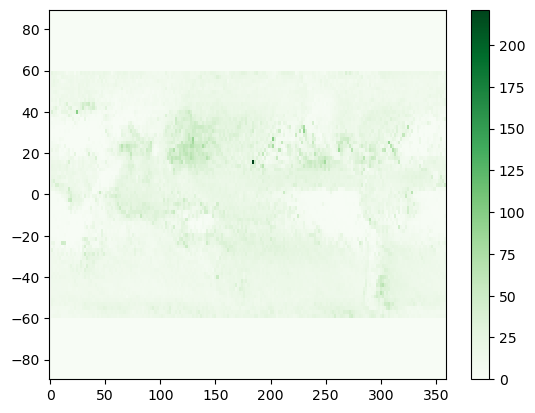

In [77]:
#
Lon, Lat = np.meshgrid(lons, lats)
plt.pcolormesh(Lon, Lat, scale[6], cmap='Greens')
plt.colorbar()

In [78]:
#
# Now upsample shape to daily
#
times = times = pd.date_range(start = '1950-01-01', end='1951-01-01', freq='M')
#
# lats, lons are defined
#
dT1 = xr.Dataset({'shape': (['time','lat','lon'],shape_warm)},coords={'time': times,'lat': lats, 'lon': lons})
times = times = pd.date_range(start = '1951-01-01', end='1952-01-01', freq='M')
dT2 = xr.Dataset({'shape': (['time','lat','lon'],shape_warm)},coords={'time': times, 'lat': lats, 'lon': lons})
times = times = pd.date_range(start = '1952-01-01', end='1953-01-01', freq='M')
dT3 = xr.Dataset({'shape': (['time','lat','lon'],shape_warm)},coords={'time': times, 'lat': lats, 'lon': lons})
dT = xr.concat([dT1,dT2,dT3],dim='time')
#
Daily = dT.resample(time='D').interpolate('cubic')
Daily

<xarray.Dataset>
Dimensions:  (time: 1066, lat: 96, lon: 192)
Coordinates:
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
  * time     (time) datetime64[ns] 1950-01-31 1950-02-01 ... 1952-12-31
Data variables:
    shape    (time, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

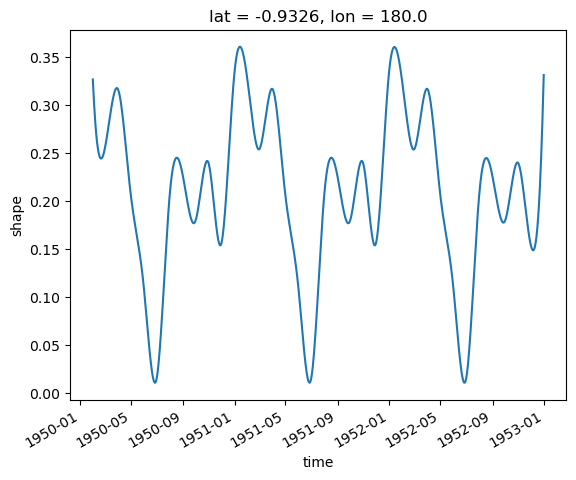

In [79]:
Daily.shape[:,48,96].plot()

In [80]:
#
foo = Daily.shape[335:700]
foo = np.where(foo < 0.0, 0.0, foo)
torch.save(foo,outpath+'shapeAC_Warm.pt')

In [81]:
#
# Now upsample scale to daily
#
times = times = pd.date_range(start = '1950-01-01', end='1951-01-01', freq='M')
#
# lats, lons, are defined
#
dT1 = xr.Dataset({'scale': (['time','lat','lon'],scale_warm)},coords={'time': times,'lat': lats, 'lon': lons})
times = times = pd.date_range(start = '1951-01-01', end='1952-01-01', freq='M')
dT2 = xr.Dataset({'scale': (['time','lat','lon'],scale_warm)},coords={'time': times, 'lat': lats, 'lon': lons})
times = times = pd.date_range(start = '1952-01-01', end='1953-01-01', freq='M')
dT3 = xr.Dataset({'scale': (['time','lat','lon'],scale_warm)},coords={'time': times, 'lat': lats, 'lon': lons})
dT = xr.concat([dT1,dT2,dT3],dim='time')
#
Daily = dT.resample(time='D').interpolate('cubic')
Daily

<xarray.Dataset>
Dimensions:  (time: 1066, lat: 96, lon: 192)
Coordinates:
  * lat      (lat) float64 88.57 86.72 84.86 83.0 ... -83.0 -84.86 -86.72 -88.57
  * lon      (lon) float64 0.0 1.875 3.75 5.625 7.5 ... 352.5 354.4 356.2 358.1
  * time     (time) datetime64[ns] 1950-01-31 1950-02-01 ... 1952-12-31
Data variables:
    scale    (time, lat, lon) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0

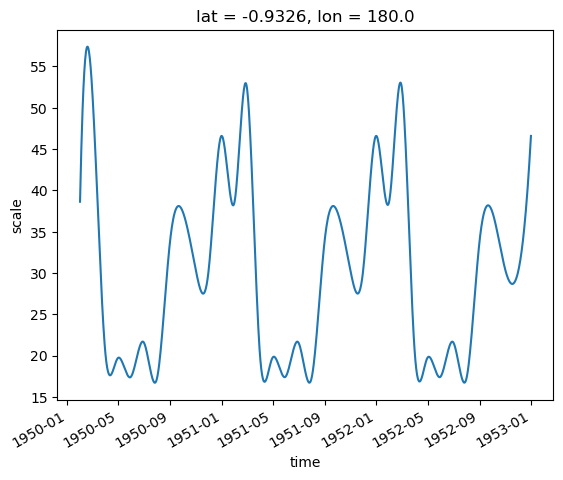

In [82]:
Daily.scale[:,48,96].plot()

In [83]:
#
foo = Daily.scale[335:700]
foo = np.where(foo < 0.0, 0.0, foo)
torch.save(foo,outpath+'scaleAC_Warm.pt')